# Advanced Predictive Maintenance: Turbofan Engine Degradation (NASA C-MAPSS)

This project analyzes the C-MAPSS dataset provided by NASA's Ames Center of Excellence for Forecasting (PCoE). The simulation records multiple sensor channels to characterize the evolution of turbofan engine failures.

Instead of predicting the exact Remaining Useful Life (RUL) using classical regression, we modeled the problem as a **Multiclass Classification (Healthy, Alert, Critical)**.

To process both the dynamic temporal degradation (sliding sensor windows) and the static context (engine DNA and operating regimes via Embeddings), we developed a benchmark of five deep learning architectures. The benchmark evaluates the F1-Score (Macro), Accuracy (Precision), and Execution Time (Efficiency).

---
## 1. Importing Libraries and Configuring the Environment

In [ ]:
import pandas as pd
import numpy as np
import os
import math
import time
import warnings
import matplotlib.pyplot as plt 
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Scikit-Learn
from sklearn.preprocessing import StandardScaler, LabelEncoder, FunctionTransformer, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, accuracy_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Device Configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f" Using device: {device}")

 Usando dispositivo: cuda


---
## 2. Data Ingestion (C-MAPSS)
We load the 4 sub-datasets from the local path. A unique global identifier (`global_unit`) is guaranteed for each engine, essential to avoid mixing different time series.

In [22]:
# Local path where the dataset is located
path = r"C:\Users\arman\OneDrive\Documentos\Proyectos de programacion\Proyectos sin haberse publicado\ML-DL-SQL-MongoDB\603 Serie_de_tiempo_Clasificacion_multiclase_PyTorch_Deep_Learning_UNIVARIADO_Y_MULTIVARIADO\data"

def load_and_combine_data(data_dir):
    # Column names according to official NASA C-MAPSS documentation
    index_names = ['unit_number', 'time_in_cycles']
    setting_names = ['op_setting_1', 'op_setting_2', 'op_setting_3']
    sensor_names = [f'sensor_{i}' for i in range(1,22)]
    col_names = index_names + setting_names + sensor_names
    
    datasets = ['FD001', 'FD002', 'FD003', 'FD004']
    train_list = []
    
    for ds in datasets:
        file_path = os.path.join(data_dir, f'train_{ds}.txt')
        if os.path.exists(file_path):
            # The separator in these files is a space.
            df = pd.read_csv(file_path, sep='\\s+', header=None, names=col_names)
            df['dataset_id'] = ds
            # Make the unit_number globally unique
            df['global_unit'] = df['dataset_id'] + '_' + df['unit_number'].astype(str)
            train_list.append(df)
        else:
            print(f"⚠️ Warning: File not found {file_path}")
            
    if not train_list:
        raise ValueError("No data was found in the specified path. Please check the files.")
        
    return pd.concat(train_list, ignore_index=True)

data = load_and_combine_data(path)
print(f"Total dimensions of the dataset: {data.shape}")
data.head()

Total dimensions of the dataset: (160359, 28)


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,global_unit
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001,FD001_1
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001,FD001_1
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001,FD001_1
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001,FD001_1
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001,FD001_1


---
## 3. Problem Transformation and Cleanup
In the aeronautical industry, phased early warnings (risk zones) are preferable to a strict numerical regression that can be misinterpreted. We define the target variable ranges:
* **Healthy:** More than 60 cycles remaining until failure.

* **Alert:** Between 30 and 60 cycles remaining (Maintenance is scheduled).

* **Critical:** Less than 30 cycles until catastrophic failure (AOG Imminent).

In [23]:
def build_multiclass_target(df):
    df = df.copy()
    # Calculate actual Remaining Useful Life (RUL)
    max_cycles = df.groupby('global_unit')['time_in_cycles'].transform('max')
    df['RUL'] = max_cycles - df['time_in_cycles']
    
    # Create the target variable Multiclass
    df['failure_type'] = 'Healthy'
    df.loc[df['RUL'] <= 60, 'failure_type'] = 'Alert'
    df.loc[df['RUL'] <= 30, 'failure_type'] = 'Critical'
    
    return df

data = build_multiclass_target(data)
print("Distribution of Operating Classes:")
display(data["failure_type"].value_counts().to_frame())

# Basic Cleaning
data = data.drop_duplicates()

# Remove invariant sensors (Variance 0)
sensor_cols = [col for col in data.columns if 'sensor' in col]
std_dev = data[sensor_cols].std()
invariant_sensors = std_dev[std_dev < 1e-6].index.tolist()
print(f"\nEliminating invariant sensors (without useful signal): {invariant_sensors}")
data = data.drop(columns=invariant_sensors + ['RUL']) # RUL is removed to prevent direct data leakage.

Distribution of Operating Classes:


,count
failure_type,
Healthy,117110
Critical,21979
Alert,21270



Eliminating invariant sensors (without useful signal): []


---
## 4. Dynamic Exploratory Analysis (EDA)
Visualization of the behavior of representative sensors as the FD001_1 motor passes through operational risk zones.

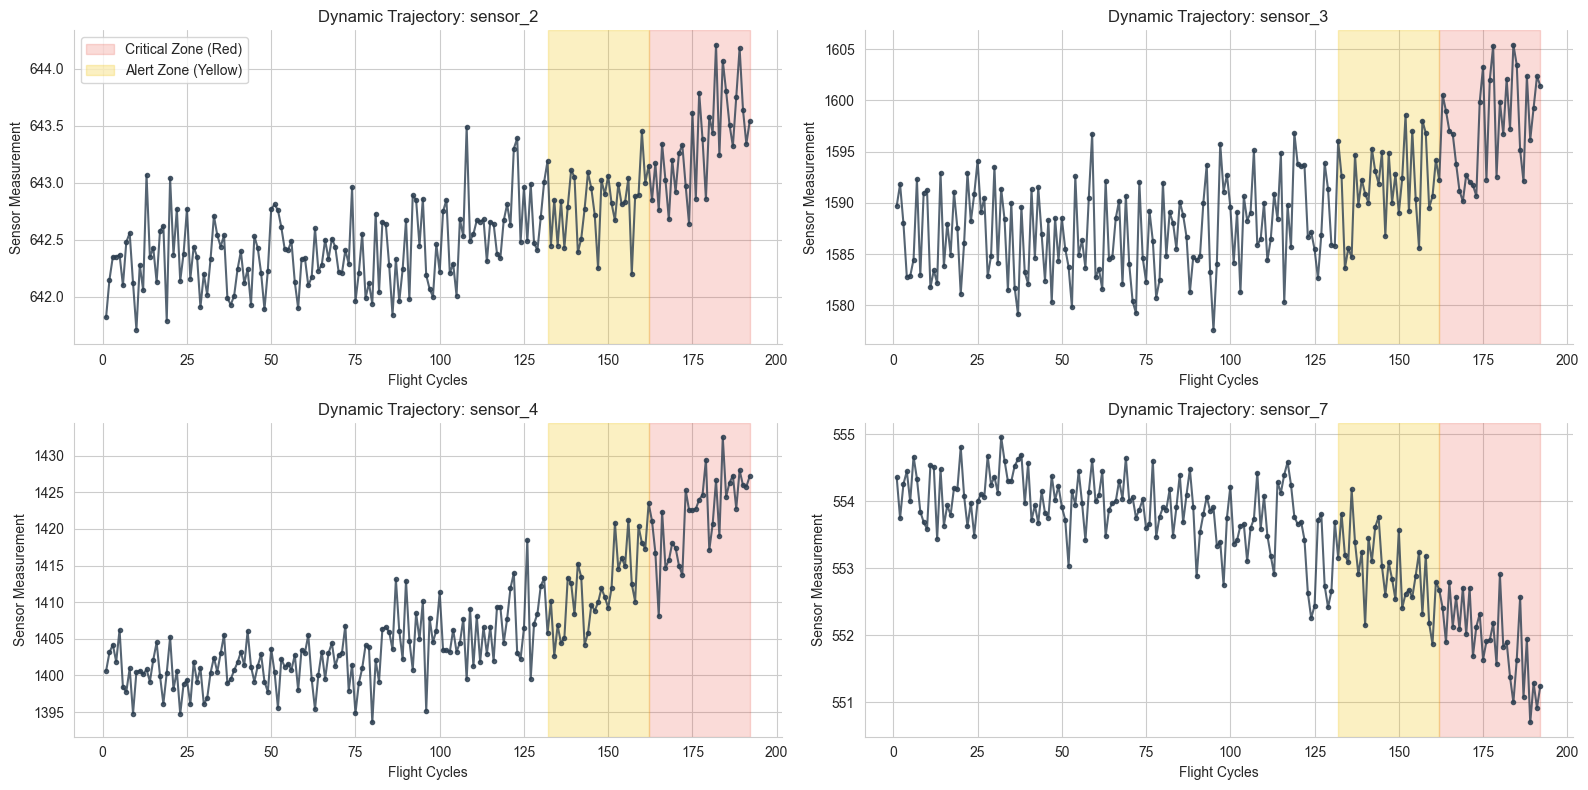

In [ ]:
df_plot = data.copy()
cols_to_plot = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']
cols_to_plot = [col for col in cols_to_plot if col in df_plot.columns]

# Temporal evolution of degradation for the Example Engine
unit_example = df_plot[df_plot['global_unit'] == 'FD001_1']

plt.figure(figsize=(16, 8))
sns.set_style('whitegrid')
for i, sensor in enumerate(cols_to_plot[:4], 1):
    plt.subplot(2, 2, i)
    plt.plot(unit_example['time_in_cycles'], unit_example[sensor], color='#2c3e50', marker='.', alpha=0.8, linewidth=1.5)
    plt.title(f'Dynamic Trajectory: {sensor}', fontsize=12)
    plt.xlabel('Flight Cycles')
    plt.ylabel('Sensor Measurement')
    
    # Visual mapping of risk zones (The Target)
    max_cyc = unit_example['time_in_cycles'].max()
    plt.axvspan(max_cyc - 30, max_cyc, color='#e74c3c', alpha=0.2, label='Critical Zone (Red)')
    plt.axvspan(max_cyc - 60, max_cyc - 30, color='#f1c40f', alpha=0.25, label='Alert Zone (Yellow)')
    if i == 1: 
        plt.legend(loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()

---
## 5. Feature Engineering, Partitioning, and Scaling
**Critical Rule:** To prevent data leakage in forecast time series, we divide the dataset, ensuring that the time series from the same engine (`global_unit`) fall entirely into a single set (Train, Val, or Test).

In [ ]:
def split_by_unit(df, test_size=0.15, val_size=0.15):
    gss1 = GroupShuffleSplit(n_splits=1, test_size=(test_size + val_size), random_state=42)
    train_idx, temp_idx = next(gss1.split(df, groups=df['global_unit']))
    temp_df = df.iloc[temp_idx].copy()
    
    proportion_test = test_size / (test_size + val_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=proportion_test, random_state=42)
    val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['global_unit']))
    
    return df.iloc[train_idx].copy(), temp_df.iloc[val_idx].copy(), temp_df.iloc[test_idx].copy()

train_data, val_data, test_data = split_by_unit(data)

def feature_engineering(df):
    df = df.copy()
    sensor_cols = [c for c in df.columns if 'sensor' in c]
    
    # DYNAMIC FE: High-frequency noise smoothing 
    grouped = df.groupby('global_unit')[sensor_cols]
    
    roll_mean = grouped.transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    roll_mean.columns = [f'{c}_roll_mean' for c in sensor_cols]
    
    roll_std = grouped.transform(lambda x: x.rolling(window=5, min_periods=1).std().fillna(0))
    roll_std.columns = [f'{c}_roll_std' for c in sensor_cols]
    
    df = pd.concat([df, roll_mean, roll_std], axis=1)
        
    # STATIC FE: Engine Signature (Baseline wear in the first 5 flights)
    # It calculates the average value of the sensors in the first 5 cycles of each unit, generating a baseline DataFrame per unit.
    baseline_df = df[df['time_in_cycles'] <= 5].groupby('global_unit')[sensor_cols].mean()
    baseline_df.columns = [f'static_base_{c}' for c in baseline_df.columns]
    df = df.merge(baseline_df, on='global_unit', how='left')
    df = df.drop(columns=['unit_number'])
    
    return df

feat_engineer = FunctionTransformer(feature_engineering, validate=False)
train_eng = feat_engineer.fit_transform(train_data)
val_eng   = feat_engineer.transform(val_data)
test_eng  = feat_engineer.transform(test_data)

# Ordinal Target Encoding
le_y = LabelEncoder()
le_y.fit(['Healthy', 'Alert', 'Critical'])
y_train_enc, y_val_enc, y_test_enc = [le_y.transform(d['failure_type']) for d in (train_eng, val_eng, test_eng)]
train_eng, val_eng, test_eng = [d.drop(columns=['failure_type']) for d in (train_eng, val_eng, test_eng)]

# Standard Scaling of Sensors (Z-Score Normalization)
bypass_cols = ['global_unit', 'dataset_id', 'time_in_cycles']
num_cols = [c for c in train_eng.columns if c not in bypass_cols]

preprocessor = ColumnTransformer([
    ("scaler", StandardScaler(), num_cols)
], remainder="passthrough", verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")
X_train_scaled = preprocessor.fit_transform(train_eng)
X_val_scaled   = preprocessor.transform(val_eng)
X_test_scaled  = preprocessor.transform(test_eng)

# Categorical Encoder for creating Embeddings in PyTorch
le_cat = LabelEncoder()
X_train_scaled['dataset_id_enc'] = le_cat.fit_transform(X_train_scaled['dataset_id']) + 1
X_val_scaled['dataset_id_enc']   = le_cat.transform(X_val_scaled['dataset_id']) + 1
X_test_scaled['dataset_id_enc']  = le_cat.transform(X_test_scaled['dataset_id']) + 1
cat_cardinalities = {'dataset_id_enc': len(le_cat.classes_) + 1}

print("Feature Engineering, Clean Partitioning and Z-Score Scaling Completed.")

Feature Engineering, Clean Partitioning and Z-Score Scaling Completed.


---
## 6. Sliding Windows Modeling
Converts the 2D tabular dataset into three-dimensional tensors `[Batch, Time_Steps, Features]` ready to be consumed by PyTorch architectures.

In [26]:
def create_sequences_by_engine(df, y, seq_length=30):
    dyn_cols = [c for c in df.columns if ('sensor' in c or 'op_setting' in c) and 'static' not in c]
    stat_num_cols = [c for c in df.columns if 'static' in c]
    stat_cat_cols = ['dataset_id_enc']
    
    X_dyn_list, X_stat_num_list, X_stat_cat_list, y_list = [], [], [], []
    df['target'] = y
    
    for _, group in df.groupby('global_unit'):
        dyn_data = group[dyn_cols].values
        stat_num_data = group[stat_num_cols].iloc[0].values 
        stat_cat_data = group[stat_cat_cols].iloc[0].values
        target_data = group['target'].values
        
       # Creating windows (1-step shift)
        for i in range(len(group) - seq_length + 1):
            X_dyn_list.append(dyn_data[i : i + seq_length])
            X_stat_num_list.append(stat_num_data)
            X_stat_cat_list.append(stat_cat_data)
            y_list.append(target_data[i + seq_length - 1])
            
    return np.array(X_dyn_list), np.array(X_stat_num_list), np.array(X_stat_cat_list), np.array(y_list)

SEQ_LENGTH = 30
X_train_dyn, X_train_stat_num, X_train_stat_cat, y_train_seq = create_sequences_by_engine(X_train_scaled, y_train_enc, SEQ_LENGTH)
X_val_dyn, X_val_stat_num, X_val_stat_cat, y_val_seq         = create_sequences_by_engine(X_val_scaled, y_val_enc, SEQ_LENGTH)
X_test_dyn, X_test_stat_num, X_test_stat_cat, y_test_seq       = create_sequences_by_engine(X_test_scaled, y_test_enc, SEQ_LENGTH)

# Weight balancing due to natural imbalance (Healthy Class is majority)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_seq), y=y_train_seq)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

def build_dataloaders(X_dyn, X_num, X_cat, y, batch_size=256, shuffle=True):
    dataset = TensorDataset(
        torch.tensor(X_dyn, dtype=torch.float32),
        torch.tensor(X_num, dtype=torch.float32),
        torch.tensor(X_cat[:, 0], dtype=torch.long),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = build_dataloaders(X_train_dyn, X_train_stat_num, X_train_stat_cat, y_train_seq, shuffle=True)
val_loader   = build_dataloaders(X_val_dyn, X_val_stat_num, X_val_stat_cat, y_val_seq, shuffle=False)
test_loader  = build_dataloaders(X_test_dyn, X_test_stat_num, X_test_stat_cat, y_test_seq, shuffle=False)

print(f"Ready-to-use 3D dynamic tensioners (Train): {X_train_dyn.shape}")

Ready-to-use 3D dynamic tensioners (Train): (98582, 30, 66)


---
## 7. Advanced Deep Learning Architectures
Design and implementation of 5 high-performance architectures in PyTorch. All merge the representation of the dynamic temporal window with the static characteristics of the engine.

In [ ]:
input_dyn_sz = X_train_dyn.shape[2]
input_stat_sz = X_train_stat_num.shape[1]

# ==========================================
# MODEL 1: FCN (Baseline Classic and Strong)
# ==========================================
class FCNBaseline(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        # cat_cardinalities['dataset_id_enc'] is the number of unique categories in the variable 'dataset_id_enc' (column being encoded)
        self.emb = nn.Embedding(cat_cardinalities['dataset_id_enc'] + 1, 10, padding_idx=0)
        # Conv1d receives (Batch, Channels, Length)
        self.conv1 = nn.Conv1d(input_dyn_sz, 128, 8, padding='same')
        self.bn1 = nn.BatchNorm1d(128)
        self.conv2 = nn.Conv1d(128, 256, 5, padding='same')
        self.bn2 = nn.BatchNorm1d(256)
        self.conv3 = nn.Conv1d(256, 128, 3, padding='same')
        self.bn3 = nn.BatchNorm1d(128)
        
        self.mlp = nn.Sequential(
            nn.Linear(128 + input_stat_sz + 10, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_dyn, x_num, x_cat):
        x = x_dyn.permute(0, 2, 1) # [B, F, S]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        # Global Average Pooling
        h = x.mean(dim=2) 
        
        emb_out = self.emb(x_cat)
        combined = torch.cat([h, x_num, emb_out], dim=1)
        return self.mlp(combined)

# ==========================================
# MODEL 2: InceptionTime (SOTA CNN Time Series)
# ==========================================
class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        bottleneck_size = 32 if in_channels > 32 else in_channels
        self.bottleneck = nn.Conv1d(in_channels, bottleneck_size, 1, bias=False) if in_channels > 32 else nn.Identity()
        
        self.conv1 = nn.Conv1d(bottleneck_size, out_channels, kernel_size=10, padding='same', bias=False)
        self.conv2 = nn.Conv1d(bottleneck_size, out_channels, kernel_size=20, padding='same', bias=False)
        self.conv3 = nn.Conv1d(bottleneck_size, out_channels, kernel_size=40, padding='same', bias=False)
        
        self.maxpool = nn.MaxPool1d(3, stride=1, padding=1)
        self.conv_pool = nn.Conv1d(in_channels, out_channels, 1, bias=False)
        
        self.bn = nn.BatchNorm1d(out_channels * 4)

    def forward(self, x):
        x_bot = self.bottleneck(x)
        c1 = self.conv1(x_bot)
        c2 = self.conv2(x_bot)
        c3 = self.conv3(x_bot)
        p1 = self.conv_pool(self.maxpool(x))
        out = torch.cat([c1, c2, c3, p1], dim=1)
        return F.relu(self.bn(out))

class InceptionTime(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.inception1 = InceptionModule(input_dyn_sz, 32)
        self.inception2 = InceptionModule(128, 32)
        self.emb = nn.Embedding(cat_cardinalities['dataset_id_enc'] + 1, 10, padding_idx=0)
        
        self.mlp = nn.Sequential(
            nn.Linear(128 + input_stat_sz + 10, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )
        
    def forward(self, x_dyn, x_num, x_cat):
        x = x_dyn.permute(0, 2, 1) # [B, F, S]
        x = self.inception1(x)
        x = self.inception2(x)
        h = x.mean(dim=2) # GAP
        
        emb_out = self.emb(x_cat)
        combined = torch.cat([h, x_num, emb_out], dim=1)
        return self.mlp(combined)

# ==========================================
# MODEL 3: Time Series Transformer
# ==========================================
# UTILITY: Positional Encoding for Transformers
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.input_linear = nn.Linear(input_dyn_sz, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=128, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        
        self.emb = nn.Embedding(cat_cardinalities['dataset_id_enc'] + 1, 10, padding_idx=0)
        self.mlp = nn.Sequential(
            nn.Linear(d_model + input_stat_sz + 10, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_dyn, x_num, x_cat):
        x_t = self.input_linear(x_dyn)
        x_t = self.pos_encoder(x_t)
        out_tf = self.transformer_encoder(x_t)
        
        h = out_tf.mean(dim=1) # Global Average Pooling
        
        emb_out = self.emb(x_cat)
        combined = torch.cat([h, x_num, emb_out], dim=1)
        return self.mlp(combined)

# ==========================================
# MODEL 4: PatchTST (Patch Time Series Transformer - Classification)
# ==========================================
class PatchTST(nn.Module):
    def __init__(self, seq_len=SEQ_LENGTH, patch_len=10, stride=10, n_features=input_dyn_sz, d_model=64, nhead=4):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.num_patches = int((seq_len - patch_len) / stride + 1)
        
        self.patch_proj = nn.Linear(patch_len * n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model) 
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        self.emb = nn.Embedding(cat_cardinalities['dataset_id_enc'] + 1, 10, padding_idx=0)
        self.mlp = nn.Sequential(
            nn.Linear(d_model + input_stat_sz + 10, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )

    def forward(self, x_dyn, x_num, x_cat):
        # Patch Creation
        patches = x_dyn.unfold(dimension=1, size=self.patch_len, step=self.stride) 
        B, num_patches, F, P = patches.shape
        patches = patches.reshape(B, num_patches, F * P)
        
        x_t = self.patch_proj(patches)
        x_t = self.pos_encoder(x_t) 
        out = self.transformer(x_t)
        h = out.mean(dim=1)
        
        emb_out = self.emb(x_cat)
        combined = torch.cat([h, x_num, emb_out], dim=1)
        return self.mlp(combined)

# ==========================================
# MODEL 5: ConvTransformer (Hybrid CNN-Self Attention)
# ==========================================
class ConvTransformer(nn.Module):
    def __init__(self, n_features=input_dyn_sz, d_model=64, nhead=4):
        super().__init__()
        self.conv = nn.Conv1d(in_channels=n_features, out_channels=d_model, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm1d(d_model)
        self.pos_encoder = PositionalEncoding(d_model) 
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        self.emb = nn.Embedding(cat_cardinalities['dataset_id_enc'] + 1, 10, padding_idx=0)
        self.mlp = nn.Sequential(
            nn.Linear(d_model + input_stat_sz + 10, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )

    def forward(self, x_dyn, x_num, x_cat):
        x = x_dyn.permute(0, 2, 1) # [B, F, S]
        x = F.relu(self.bn(self.conv(x)))
        x = x.permute(0, 2, 1) # [B, S, F]
        x = self.pos_encoder(x) 
        
        out = self.transformer(x)
        h = out.mean(dim=1)
        
        emb_out = self.emb(x_cat)
        combined = torch.cat([h, x_num, emb_out], dim=1)
        return self.mlp(combined)

---
## 8. Training Loop (Early Stopping and Time Profiling)
A routine that will iterate over all models. We implemented **Early Stopping** to mitigate overfitting and recorded the **Inference and Training Time** as a critical feasibility metric.

In [ ]:
def train_evaluate_classification(model, model_name, train_loader, val_loader, epochs=25, lr=1e-3, patience=4):
    print(f"\n{'='*45}\nTraining: {model_name}\n{'='*45}")
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    best_val, no_improve = float("inf"), 0
    best_state = None
    start_time = time.time()
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for x_dyn, x_num, x_cat, yb in train_loader:
            x_dyn, x_num, x_cat, yb = x_dyn.to(device), x_num.to(device), x_cat.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(x_dyn, x_num, x_cat)
            loss = criterion(preds, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        
        train_mean = train_loss / len(train_loader)
            
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_dyn, x_num, x_cat, yb in val_loader:
                x_dyn, x_num, x_cat, yb = x_dyn.to(device), x_num.to(device), x_cat.to(device), yb.to(device)
                preds = model(x_dyn, x_num, x_cat)
                loss = criterion(preds, yb)
                val_loss += loss.item()
                
        val_mean = val_loss / len(val_loader)
        
        # Early Stopping Logic
        if val_mean < best_val:
            best_val, no_improve = val_mean, 0
            best_state = model.state_dict()
            estado = "Saved"
        else:
            no_improve += 1
            estado = ""
            
        print(f"Epoch {epoch:2d} | Train Loss: {train_mean:.4f} | Val Loss: {val_mean:.4f} {estado}")
            
        if no_improve >= patience:
            print(f"Early stopping activated during the season {epoch}")
            break
            
    execution_time = time.time() - start_time
    model.load_state_dict(best_state)
    
    return model, execution_time

# Standardized inference function extracting predictions and probabilities.
def get_predictions(model, loader):
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    
    with torch.no_grad():
        for x_dyn, x_num, x_cat, yb in loader:
            x_dyn, x_num, x_cat, yb = x_dyn.to(device), x_num.to(device), x_cat.to(device), yb.to(device)
            out = model(x_dyn, x_num, x_cat)
            probs = F.softmax(out, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            y_true.extend(yb.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
    
    return np.array(y_true), np.array(y_pred), np.array(y_probs)

# Dictionary of Models
models = {
    "FCN (Baseline)": FCNBaseline().to(device),
    "InceptionTime": InceptionTime().to(device),
    "TimeSeriesTransformer": TimeSeriesTransformer().to(device),
    "PatchTST": PatchTST().to(device),
    "ConvTransformer": ConvTransformer().to(device)
}

# Dictionaries to consolidate results
benchmark_results = []
predictions_dict = {}

# Run Loop for the entire Pipeline
for name, model in models.items():
    trained_model, exec_time = train_evaluate_classification(model, name, train_loader, val_loader)
    y_true, y_pred, y_probs = get_predictions(trained_model, test_loader)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    
    benchmark_results.append({
        'Model': name,
        'Macro F1': macro_f1,
        'Accuracy': acc,
        'Time (s)': exec_time
    })

    predictions_dict[name] = {'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs}

df_results = pd.DataFrame(benchmark_results)


Training: FCN (Baseline)
Epoch  0 | Train Loss: 0.6350 | Val Loss: 1.1484 Saved
Epoch  1 | Train Loss: 0.5370 | Val Loss: 0.8267 Saved
Epoch  2 | Train Loss: 0.4958 | Val Loss: 0.6938 Saved
Epoch  3 | Train Loss: 0.4413 | Val Loss: 0.8820 
Epoch  4 | Train Loss: 0.4038 | Val Loss: 0.7097 
Epoch  5 | Train Loss: 0.3685 | Val Loss: 3.5889 
Epoch  6 | Train Loss: 0.3302 | Val Loss: 2.1157 
Early stopping activated during the season 6

Training: InceptionTime
Epoch  0 | Train Loss: 0.6133 | Val Loss: 0.6104 Saved
Epoch  1 | Train Loss: 0.4609 | Val Loss: 0.5947 Saved
Epoch  2 | Train Loss: 0.3602 | Val Loss: 0.6117 
Epoch  3 | Train Loss: 0.3018 | Val Loss: 0.5902 Saved
Epoch  4 | Train Loss: 0.2552 | Val Loss: 0.8534 
Epoch  5 | Train Loss: 0.2332 | Val Loss: 0.6717 
Epoch  6 | Train Loss: 0.2074 | Val Loss: 0.7480 
Epoch  7 | Train Loss: 0.1944 | Val Loss: 0.9254 
Early stopping activated during the season 7

Training: Vanilla Transformer
Epoch  0 | Train Loss: 0.7373 | Val Loss: 0.5682

---
## 9. Results and Comparative Graphs
We will now compare the results and computational requirements of the benchmark. We will analyze the best model by extracting its Confusion Matrix and its One-vs-Rest ROC Curve.

,Model,Macro F1,Accuracy,Time (s)
4,ConvTransformer,0.804600,0.867351,79.069864
2,Vanilla Transformer,0.802368,0.866964,71.684371
1,InceptionTime,0.783116,0.858631,49.124571
3,PatchTST,0.697062,0.784749,43.984345
0,FCN (Baseline),0.608099,0.673611,42.630304


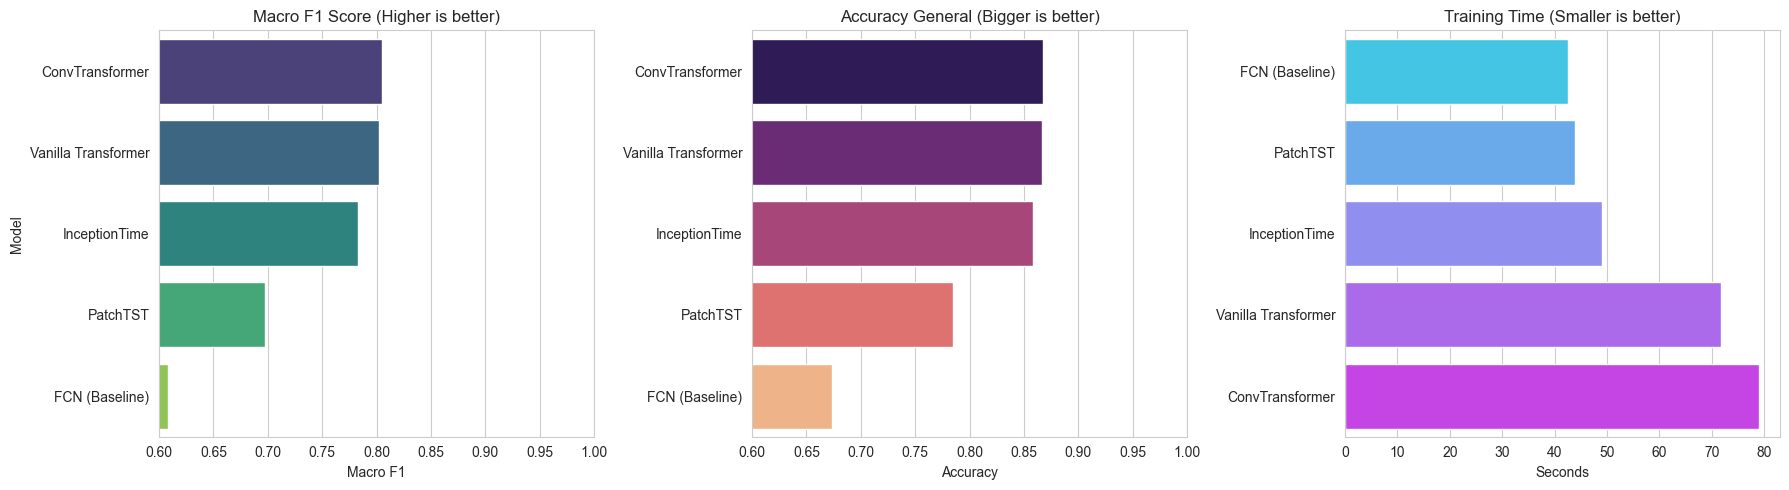


 The overall winner of the benchmark is:**ConvTransformer**


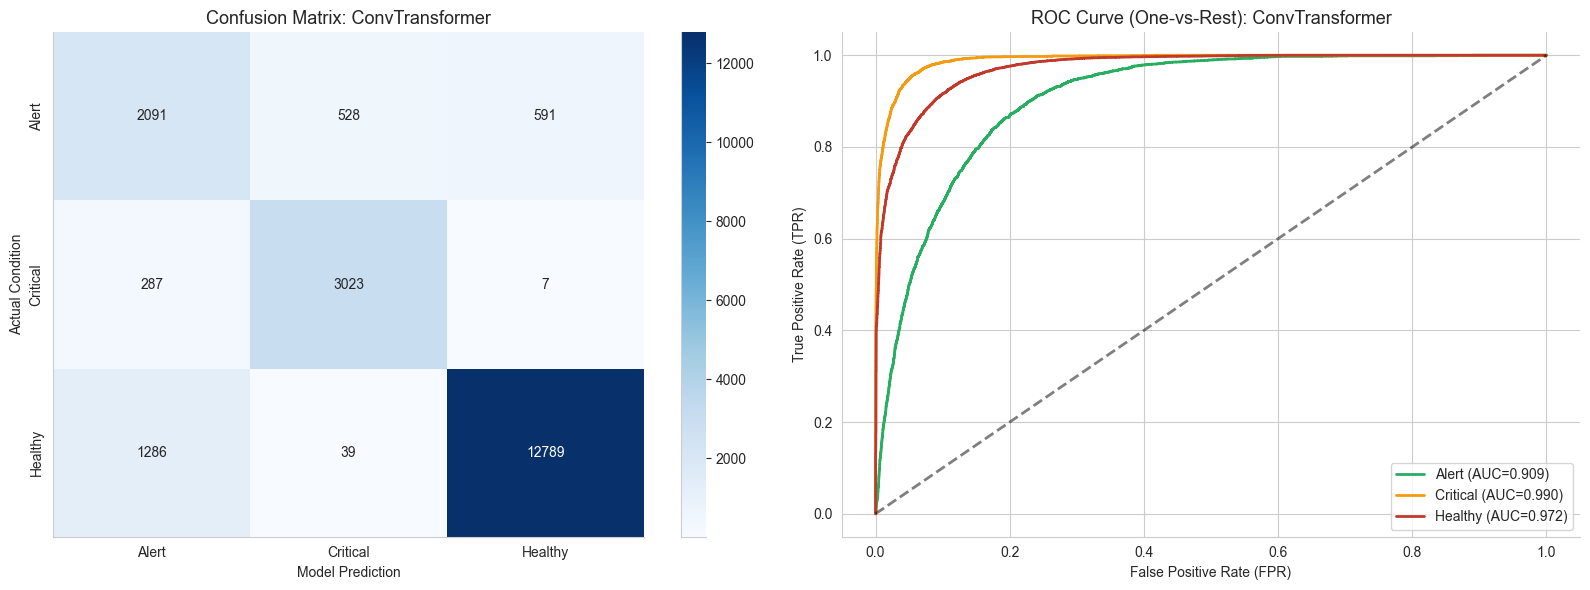


Detailed Report (ConvTransformer):
              precision    recall  f1-score   support

       Alert       0.57      0.65      0.61      3210
    Critical       0.84      0.91      0.88      3317
     Healthy       0.96      0.91      0.93     14114

    accuracy                           0.87     20641
   macro avg       0.79      0.82      0.80     20641
weighted avg       0.88      0.87      0.87     20641



In [29]:
display(df_results.sort_values(by='Macro F1', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_style('whitegrid')

# Plot Macro F1
sns.barplot(data=df_results.sort_values('Macro F1', ascending=False), x='Macro F1', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('Macro F1 Score (Higher is better)', fontsize=12)
axes[0].set_xlabel('Macro F1')
axes[0].set_xlim(0.6, 1.0)

# Plot Accuracy
sns.barplot(data=df_results.sort_values('Accuracy', ascending=False), x='Accuracy', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('Accuracy General (Bigger is better)', fontsize=12)
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0.6, 1.0)
axes[1].set_ylabel('')

# Plot Time
sns.barplot(data=df_results.sort_values('Time (s)'), x='Time (s)', y='Model', palette='cool', ax=axes[2])
axes[2].set_title('Training Time (Smaller is better)', fontsize=12)
axes[2].set_xlabel('Seconds')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# =========================================================================
# ISOLATED ANALYSIS OF THE BEST MODEL
# =========================================================================
best_model_name = df_results.loc[df_results['Macro F1'].idxmax(), 'Model']
print(f"\n The overall winner of the benchmark is:**{best_model_name}**")
best_preds = predictions_dict[best_model_name]['y_pred']
best_probs = predictions_dict[best_model_name]['y_probs']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_true, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_y.classes_, yticklabels=le_y.classes_, ax=axes[0])
axes[0].set_xlabel('Model Prediction')
axes[0].set_ylabel('Actual Condition')
axes[0].set_title(f'Confusion Matrix: {best_model_name}', fontsize=13)

# 2. Multiclass ROC Curve (One-vs-Rest)
y_test_bin = label_binarize(y_true, classes=[0, 1, 2])
colors = ['#27ae60', '#f39c12', '#c0392b']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_probs[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, color=colors[i], label=f'{le_y.inverse_transform([i])[0]} (AUC={roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title(f"ROC Curve (One-vs-Rest): {best_model_name}", fontsize=13)
axes[1].legend(loc="lower right")

sns.despine()
plt.tight_layout()
plt.show()

print(f"\nDetailed Report ({best_model_name}):")
print(classification_report(y_true, best_preds, target_names=le_y.classes_))